In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


In [4]:
dataset_link = "anlgrbz/student-demographics-online-education-dataoulad" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

100%|██████████| 42.2M/42.2M [01:28<00:00, 497kB/s]

Extracting files...


Loading dataset from /Users/reginaborovaya/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1 to ../data/raw/student-demographics-online-education-dataoulad
Moving file: /Users/reginaborovaya/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentAssessment.csv to /Users/reginaborovaya/StackFuel/projekt_learning_analytics_stackfuel/notebooks/../data/raw/student-demographics-online-education-dataoulad
Moving file: /Users/reginaborovaya/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentInfo.csv to /Users/reginaborovaya/StackFuel/projekt_learning_analytics_stackfuel/notebooks/../data/raw/student-demographics-online-education-dataoulad
Moving file: /Users/reginaborovaya/.cache/kagglehub/datasets/anlgrbz/student-demographics-online-education-dataoulad/versions/1/studentVle.csv to /Users/reginaborovaya/StackFuel/projekt_learning_analytics_stackfuel/notebook

In [5]:
files

['studentAssessment.csv',
 'studentInfo.csv',
 'studentVle.csv',
 'courses.csv',
 'vle.csv',
 'studentRegistration.csv',
 'assessments.csv']

In [6]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [7]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(173912, 5)

'Description'

,count,mean,std,min,25%,50%,75%,max
id_assessment,173912.0,26553.80,8829.78,1752.0,15022.0,25359.0,34883.0,37443.0
id_student,173912.0,705150.72,552395.19,6516.0,504429.0,585208.0,634498.0,2698588.0
date_submitted,173912.0,116.03,71.48,-11.0,51.0,116.0,173.0,608.0
is_banked,173912.0,0.01,0.10,0.0,0.0,0.0,0.0,1.0
score,173739.0,75.80,18.80,0.0,65.0,80.0,90.0,100.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
id_assessment,int64,0,188,"[14999, 1759, 34861]"
id_student,int64,0,23369,"[614039, 592151, 602066]"
date_submitted,int64,0,312,"[80, 14, 108]"
is_banked,int64,0,2,"[0, 0, 0]"
score,float64,173,101,"[61.0, 80.0, 82.0]"


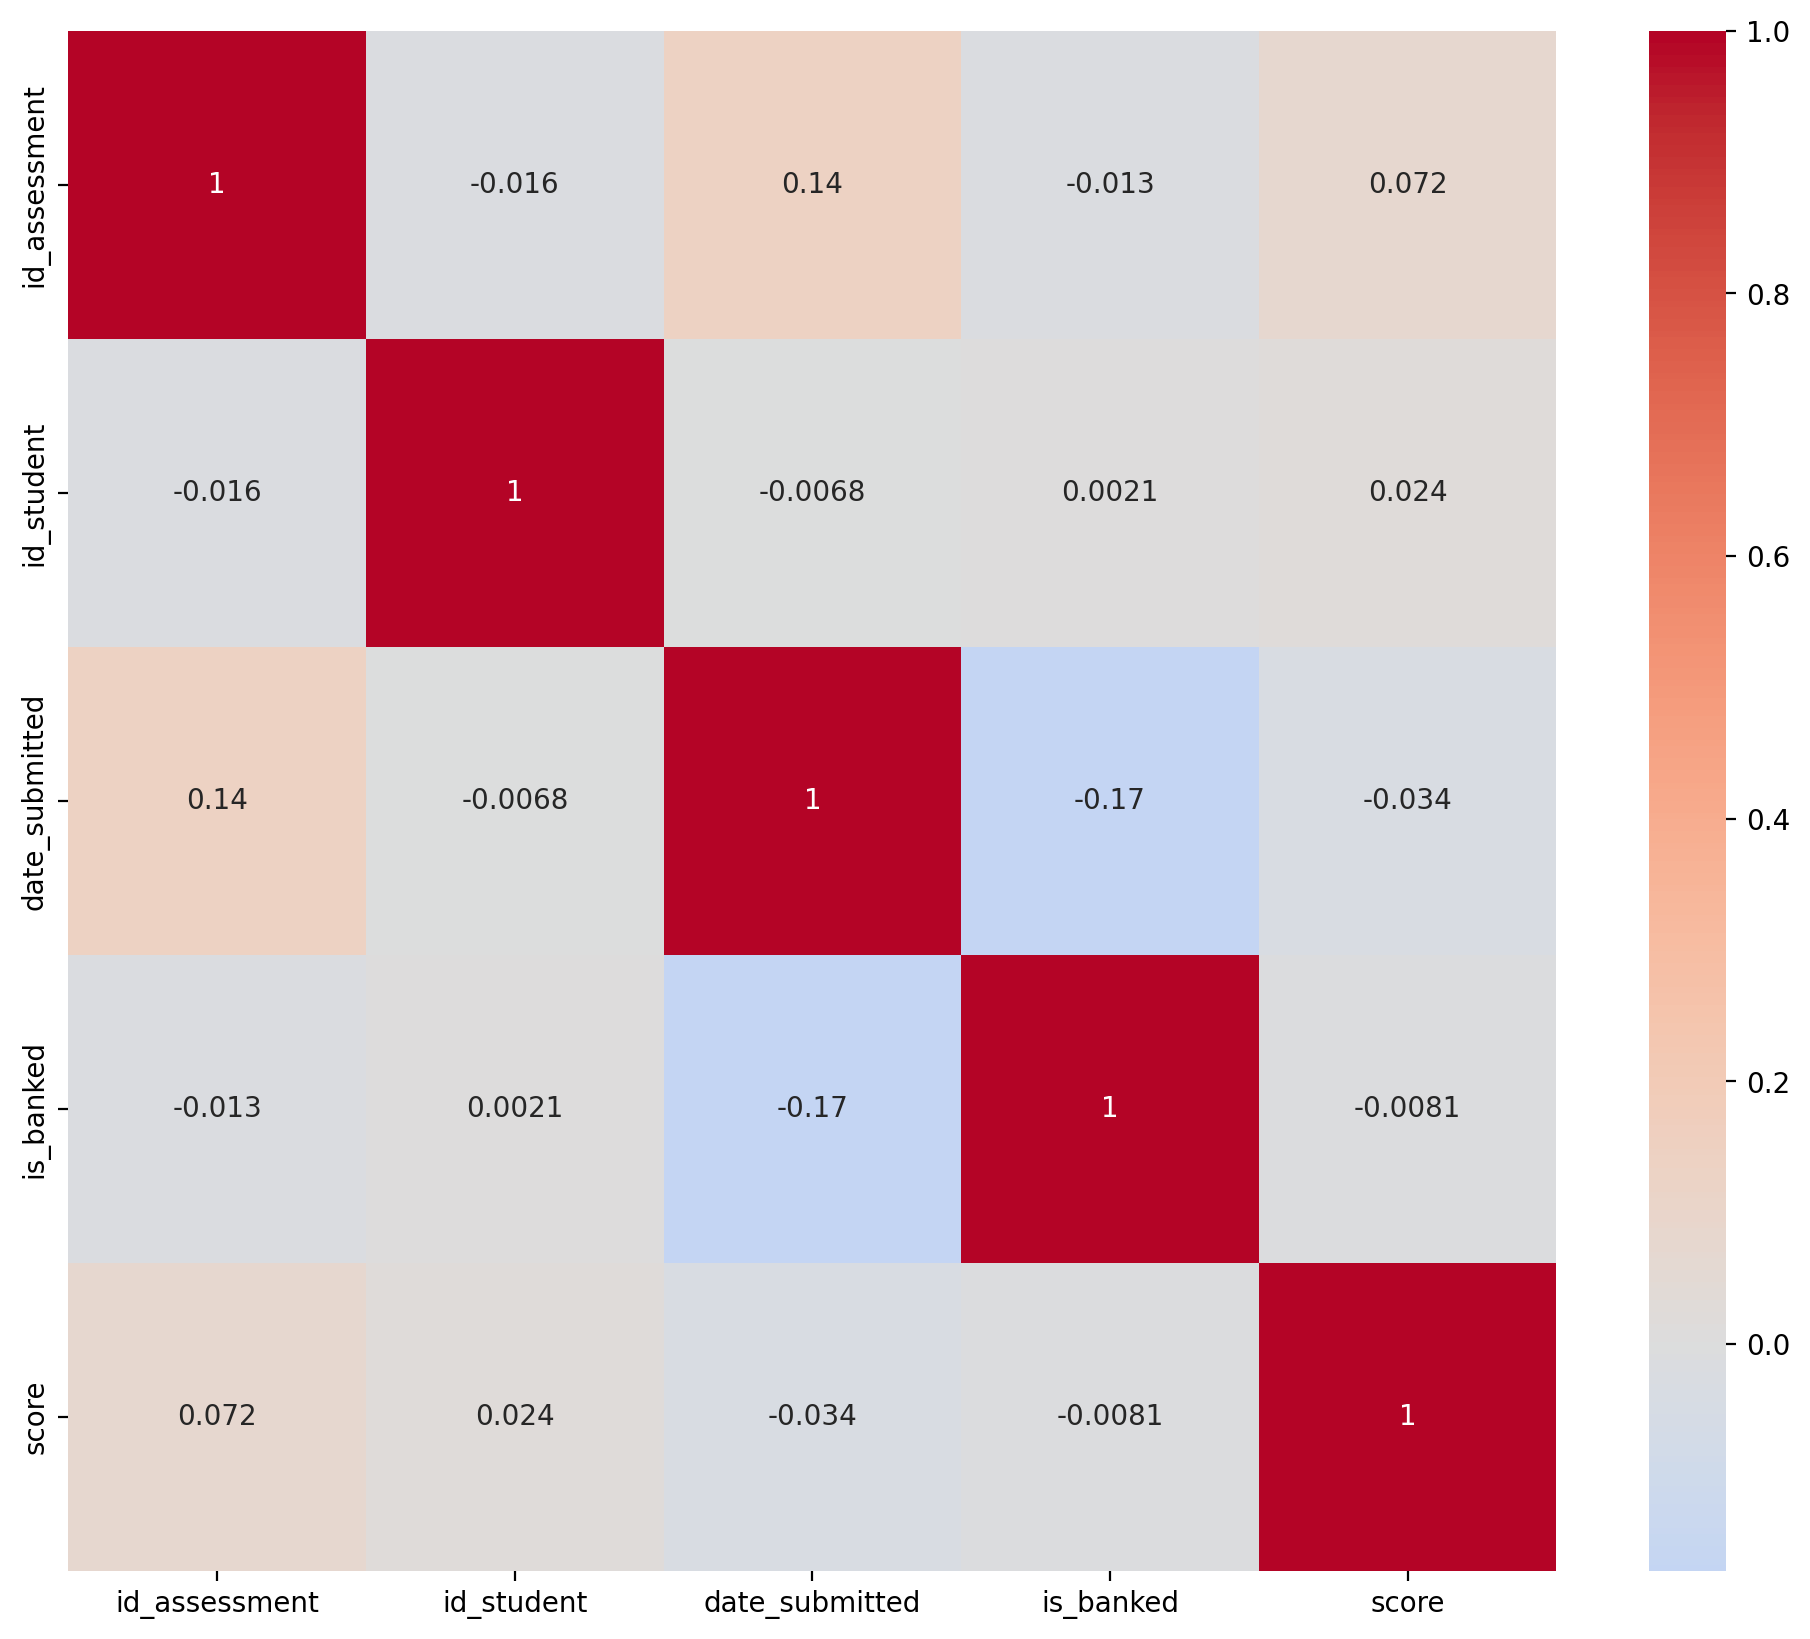

In [8]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);